IMMOVISION 360° PARIS - ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
BLOC B : DESCRIPTION UNIVARIÉE

 1. IMPORTS ET CONFIGURATION

In [4]:
import sys
print(sys.executable)

/Users/meganelegnigha/IABD/4A/Collecte et exploration de donnees/ImmoVision360_DataLake/myenv/bin/python


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn sqlalchemy psycopg2-binary scipy
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import chi2_contingency

# Configuration graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Paramètres d'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("✓ Bibliothèques chargées avec succès")
print("=" * 80)


zsh:1: no such file or directory: /Users/meganelegnigha/IABD/4A/Collecte
✓ Bibliothèques chargées avec succès


2. CONNEXION À POSTGRESQL ET CHARGEMENT DES DONNÉES

In [6]:
import urllib.parse

DB_USER = 'postgres'
DB_PASSWORD = '12345' # Remplace par ton vrai MDP
encoded_password = urllib.parse.quote_plus(DB_PASSWORD)
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'immovision'

# Création du moteur SQLAlchemy
connection_string = f'postgresql://{DB_USER}:{encoded_password}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(connection_string)

# Test de connexion
try:
    test_query = "SELECT 1 AS test"
    test_result = pd.read_sql(test_query, engine)
    print("✓ Connexion PostgreSQL établie avec succès")
    print(f"  Base : {DB_NAME}")
    print(f"  Utilisateur : {DB_USER}")
except Exception as e:
    print(f"✗ ERREUR de connexion : {e}")
    print("  Vérifiez vos paramètres DB_USER, DB_PASSWORD, etc.")
    raise

print("=" * 80)

✓ Connexion PostgreSQL établie avec succès
  Base : immovision
  Utilisateur : postgres


3. CHARGEMENT DE LA TABLE elysee_tabular

In [7]:
query = "SELECT * FROM elysee_tabular"

try:
    df_raw = pd.read_sql(query, engine)
    print(f"✓ Table 'elysee_tabular' chargée avec succès")
    print(f"  Nombre de lignes : {len(df_raw):,}")
    print(f"  Nombre de colonnes : {len(df_raw.columns)}")
    print(f"\nNom des colonnes :")
    print(f"  {list(df_raw.columns)}")
except Exception as e:
    print(f"✗ ERREUR lors du chargement : {e}")
    raise

print("=" * 80)

✓ Table 'elysee_tabular' chargée avec succès
  Nombre de lignes : 2,625
  Nombre de colonnes : 8

Nom des colonnes :
  ['id', 'calculated_host_listings_count', 'availability_365', 'host_response_rate_num', 'room_type_code', 'host_response_time_code', 'standardization_score', 'neighborhood_impact_score']


 4. TRAITEMENT DES VALEURS MANQUANTES (NULL → -1)

In [8]:
print("\n📋 ANALYSE DES VALEURS MANQUANTES (AVANT TRAITEMENT)")
print("=" * 80)

missing_summary = pd.DataFrame({
    'Variable': df_raw.columns,
    'N_Missing': df_raw.isnull().sum(),
    'Pct_Missing': 100 * df_raw.isnull().sum() / len(df_raw)
})
missing_summary = missing_summary[missing_summary['N_Missing'] > 0].sort_values('N_Missing', ascending=False)

if len(missing_summary) > 0:
    print(missing_summary.to_string(index=False))
    print(f"\n⚠️  Total de cellules vides : {df_raw.isnull().sum().sum():,}")
else:
    print("✓ Aucune valeur manquante détectée dans la table brute")

# Remplissage des valeurs manquantes par -1
df = df_raw.fillna(-1)

print("\n" + "=" * 80)
print("✓ TRAITEMENT APPLIQUÉ : Toutes les valeurs NULL remplacées par -1")
print("  Convention : -1 = 'information non disponible'")
print("  À distinguer des 0 métier (ex: 0 jour de disponibilité = fermé)")
print("=" * 80)

# Vérification post-traitement
assert df.isnull().sum().sum() == 0, "ERREUR : Il reste des valeurs manquantes !"
print("✓ Vérification : Aucune valeur NULL restante dans le DataFrame")


📋 ANALYSE DES VALEURS MANQUANTES (AVANT TRAITEMENT)
               Variable  N_Missing  Pct_Missing
 host_response_rate_num        681        25.94
host_response_time_code        681        25.94

⚠️  Total de cellules vides : 1,362

✓ TRAITEMENT APPLIQUÉ : Toutes les valeurs NULL remplacées par -1
  Convention : -1 = 'information non disponible'
  À distinguer des 0 métier (ex: 0 jour de disponibilité = fermé)
✓ Vérification : Aucune valeur NULL restante dans le DataFrame


5. VUE D'ENSEMBLE DU DATASET

In [9]:
print("\n\n📊 VUE D'ENSEMBLE DU DATASET")
print("=" * 80)

print("\n--- Structure du DataFrame ---")
print(df.info())

print("\n--- Aperçu des 5 premières lignes ---")
print(df.head())

print("\n--- Statistiques descriptives (variables numériques) ---")
print(df.describe())




📊 VUE D'ENSEMBLE DU DATASET

--- Structure du DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 2625 entries, 0 to 2624
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              2625 non-null   int64  
 1   calculated_host_listings_count  2625 non-null   int64  
 2   availability_365                2625 non-null   int64  
 3   host_response_rate_num          2625 non-null   float64
 4   room_type_code                  2625 non-null   int64  
 5   host_response_time_code         2625 non-null   float64
 6   standardization_score           2625 non-null   int64  
 7   neighborhood_impact_score       2625 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 164.2 KB
None

--- Aperçu des 5 premières lignes ---
        id  calculated_host_listings_count  availability_365  \
0  2871271                               1                96   
1  278569

6. DESCRIPTION UNIVARIÉE PAR VARIABLE

In [10]:
print("\n\n" + "=" * 80)
print("DESCRIPTION UNIVARIÉE DÉTAILLÉE")
print("=" * 80)



DESCRIPTION UNIVARIÉE DÉTAILLÉE


In [11]:
print("\n\n┌─────────────────────────────────────────────────────────────┐")
print("│ VARIABLE : id (Identifiant d'annonce)                      │")
print("│ Type : Identifiant numérique unique                        │")
print("└─────────────────────────────────────────────────────────────┘")

print(f"\nEffectif total : {len(df):,} annonces")
print(f"Valeurs uniques : {df['id'].nunique():,}")
print(f"Doublons : {len(df) - df['id'].nunique()}")

if df['id'].nunique() != len(df):
    print("⚠️  ALERTE : Des doublons d'ID existent dans la table !")
else:
    print("✓ Chaque ligne correspond à une annonce unique")

print(f"\nPlage d'identifiants : [{df['id'].min():,} — {df['id'].max():,}]")
print("\n💡 Interprétation :")
print("   L'identifiant sert uniquement au repérage des annonces.")
print("   Aucune analyse statistique (moyenne, distribution) n'est pertinente sur cette variable.")



┌─────────────────────────────────────────────────────────────┐
│ VARIABLE : id (Identifiant d'annonce)                      │
│ Type : Identifiant numérique unique                        │
└─────────────────────────────────────────────────────────────┘

Effectif total : 2,625 annonces
Valeurs uniques : 2,625
Doublons : 0
✓ Chaque ligne correspond à une annonce unique

Plage d'identifiants : [22,158 — 1,481,754,230,424,845,668]

💡 Interprétation :
   L'identifiant sert uniquement au repérage des annonces.
   Aucune analyse statistique (moyenne, distribution) n'est pertinente sur cette variable.




┌─────────────────────────────────────────────────────────────┐
│ VARIABLE : calculated_host_listings_count                  │
│ Type : Quantitative discrète (entier ≥ 1)                  │
│ Signification : Nombre d'annonces par hôte                 │
└─────────────────────────────────────────────────────────────┘

📈 Statistiques descriptives :
   Effectif analysé : 2625 annonces
   Minimum : 1 annonce(s)
   Quartile 25% (Q1) : 1
   Médiane (Q2) : 3
   Quartile 75% (Q3) : 20
   Maximum : 816 annonces
   Moyenne : 52.2 annonces/hôte
   Écart-type : 147.9

🔍 Répartition mono-annonce vs multi-annonces :
   Mono-annonce (= 1) : 1,101 annonces (41.9%)
   Multi-annonces (> 1) : 1,524 annonces (58.1%)

🏆 Top 5 des hôtes (nb d'annonces) : [816, 816, 816, 816, 816]


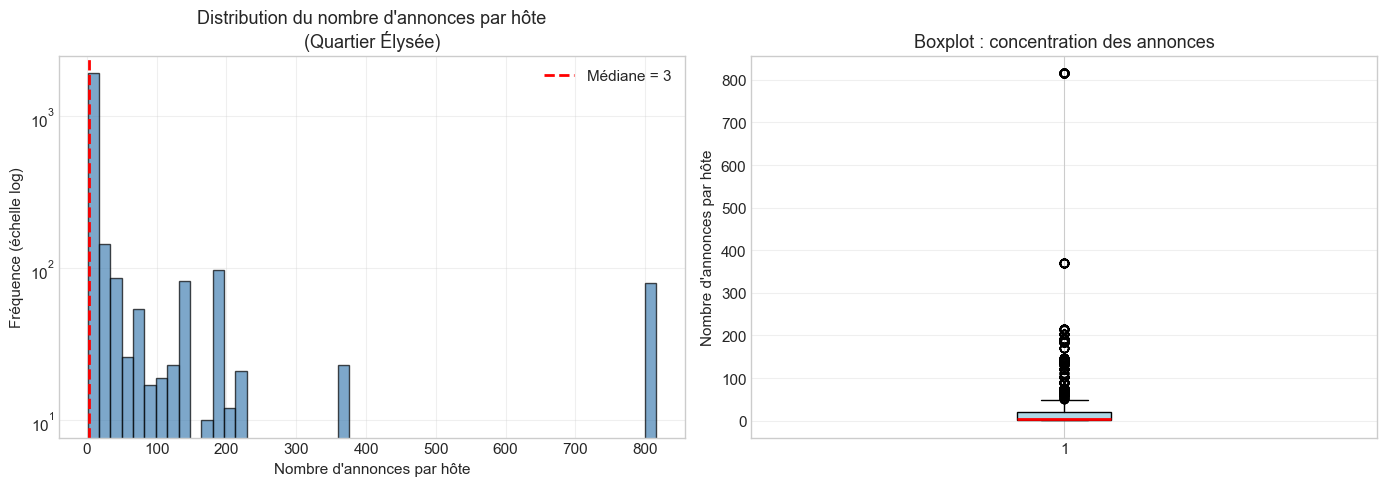


💡 Interprétation :
   La distribution est fortement asymétrique (queue longue à droite).
   La médiane très basse suggère que la plupart des hôtes ont peu d'annonces,
   mais quelques acteurs concentrent un grand nombre de logements.
   → Indice potentiel de professionnalisation de l'offre.


In [12]:
print("\n\n┌─────────────────────────────────────────────────────────────┐")
print("│ VARIABLE : calculated_host_listings_count                  │")
print("│ Type : Quantitative discrète (entier ≥ 1)                  │")
print("│ Signification : Nombre d'annonces par hôte                 │")
print("└─────────────────────────────────────────────────────────────┘")

# Statistiques descriptives
stats_host = df['calculated_host_listings_count'].describe()
print(f"\n📈 Statistiques descriptives :")
print(f"   Effectif analysé : {stats_host['count']:.0f} annonces")
print(f"   Minimum : {stats_host['min']:.0f} annonce(s)")
print(f"   Quartile 25% (Q1) : {stats_host['25%']:.0f}")
print(f"   Médiane (Q2) : {stats_host['50%']:.0f}")
print(f"   Quartile 75% (Q3) : {stats_host['75%']:.0f}")
print(f"   Maximum : {stats_host['max']:.0f} annonces")
print(f"   Moyenne : {stats_host['mean']:.1f} annonces/hôte")
print(f"   Écart-type : {stats_host['std']:.1f}")

# Répartition mono vs multi
mono_count = (df['calculated_host_listings_count'] == 1).sum()
multi_count = (df['calculated_host_listings_count'] > 1).sum()
pct_mono = 100 * mono_count / len(df)
pct_multi = 100 * multi_count / len(df)

print(f"\n🔍 Répartition mono-annonce vs multi-annonces :")
print(f"   Mono-annonce (= 1) : {mono_count:,} annonces ({pct_mono:.1f}%)")
print(f"   Multi-annonces (> 1) : {multi_count:,} annonces ({pct_multi:.1f}%)")

# Hôtes extrêmes
top_hosts = df['calculated_host_listings_count'].nlargest(5)
print(f"\n🏆 Top 5 des hôtes (nb d'annonces) : {top_hosts.tolist()}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme (échelle log)
df_positive = df[df['calculated_host_listings_count'] > 0]
axes[0].hist(df_positive['calculated_host_listings_count'], bins=50, 
             edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_xlabel('Nombre d\'annonces par hôte')
axes[0].set_ylabel('Fréquence (échelle log)')
axes[0].set_title('Distribution du nombre d\'annonces par hôte\n(Quartier Élysée)')
axes[0].axvline(stats_host['50%'], color='red', linestyle='--', 
                linewidth=2, label=f'Médiane = {stats_host["50%"]:.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df_positive['calculated_host_listings_count'], 
                vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Nombre d\'annonces par hôte')
axes[1].set_title('Boxplot : concentration des annonces')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('univarie_host_listings_count.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Interprétation :")
print("   La distribution est fortement asymétrique (queue longue à droite).")
print("   La médiane très basse suggère que la plupart des hôtes ont peu d'annonces,")
print("   mais quelques acteurs concentrent un grand nombre de logements.")
print("   → Indice potentiel de professionnalisation de l'offre.")




┌─────────────────────────────────────────────────────────────┐
│ VARIABLE : availability_365                                │
│ Type : Quantitative discrète (0 à 365 jours)               │
│ Signification : Jours disponibles sur l'année              │
└─────────────────────────────────────────────────────────────┘

📈 Statistiques descriptives :
   Effectif analysé : 2625
   Minimum : 0 jours
   Q1 : 11 jours
   Médiane : 183 jours
   Q3 : 314 jours
   Maximum : 365 jours
   Moyenne : 174.7 jours

🔍 Répartition par classe de disponibilité :
   Faible (0-90j) : 987 annonces (37.6%)
   Moyenne (91-270j) : 738 annonces (28.1%)
   Élevée (271-365j) : 900 annonces (34.3%)


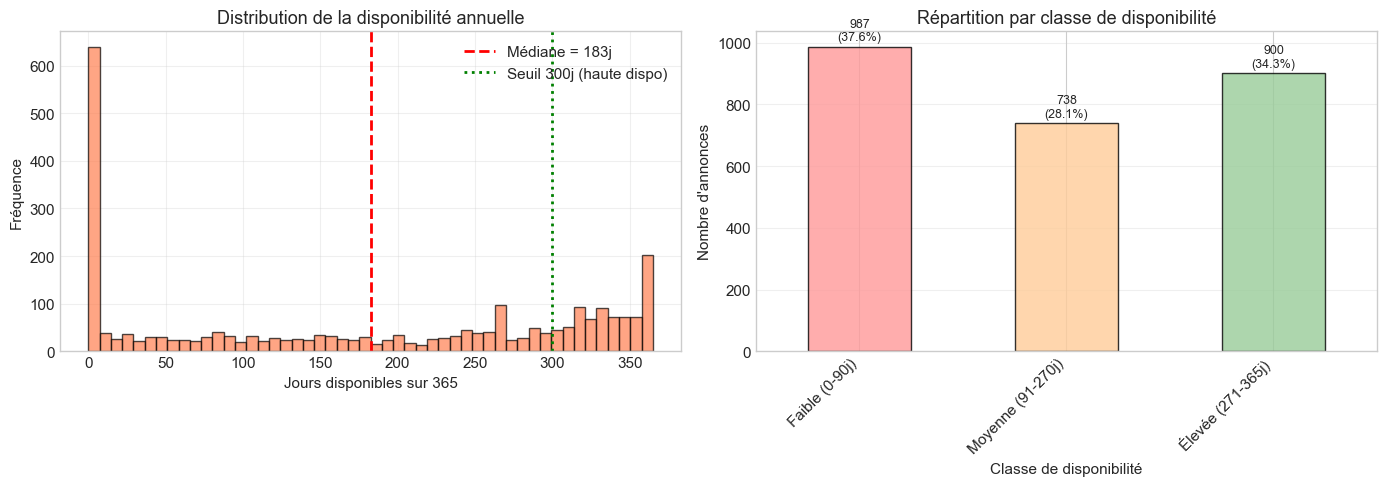


💡 Interprétation :
   Une forte disponibilité (>300j) peut signaler un usage proche de la location courte
   professionnelle plutôt que d'un partage ponctuel d'habitat.


In [13]:
print("\n\n┌─────────────────────────────────────────────────────────────┐")
print("│ VARIABLE : availability_365                                │")
print("│ Type : Quantitative discrète (0 à 365 jours)               │")
print("│ Signification : Jours disponibles sur l'année              │")
print("└─────────────────────────────────────────────────────────────┘")

stats_avail = df['availability_365'].describe()
print(f"\n📈 Statistiques descriptives :")
print(f"   Effectif analysé : {stats_avail['count']:.0f}")
print(f"   Minimum : {stats_avail['min']:.0f} jours")
print(f"   Q1 : {stats_avail['25%']:.0f} jours")
print(f"   Médiane : {stats_avail['50%']:.0f} jours")
print(f"   Q3 : {stats_avail['75%']:.0f} jours")
print(f"   Maximum : {stats_avail['max']:.0f} jours")
print(f"   Moyenne : {stats_avail['mean']:.1f} jours")

# Répartition par tranches
bins = [0, 90, 270, 365]
labels = ['Faible (0-90j)', 'Moyenne (91-270j)', 'Élevée (271-365j)']
df['avail_class'] = pd.cut(df['availability_365'], bins=bins, labels=labels, include_lowest=True)
avail_dist = df['avail_class'].value_counts().sort_index()

print(f"\n🔍 Répartition par classe de disponibilité :")
for cat, count in avail_dist.items():
    pct = 100 * count / len(df)
    print(f"   {cat} : {count:,} annonces ({pct:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['availability_365'], bins=50, edgecolor='black', 
             alpha=0.7, color='coral')
axes[0].set_xlabel('Jours disponibles sur 365')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la disponibilité annuelle')
axes[0].axvline(stats_avail['50%'], color='red', linestyle='--', 
                linewidth=2, label=f'Médiane = {stats_avail["50%"]:.0f}j')
axes[0].axvline(300, color='green', linestyle=':', 
                linewidth=2, label='Seuil 300j (haute dispo)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Diagramme en barres des classes
avail_dist.plot(kind='bar', ax=axes[1], color=['#ff9999', '#ffcc99', '#99cc99'], 
                edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Classe de disponibilité')
axes[1].set_ylabel('Nombre d\'annonces')
axes[1].set_title('Répartition par classe de disponibilité')
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(avail_dist):
    axes[1].text(i, v + 20, f'{v:,}\n({100*v/len(df):.1f}%)', 
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('univarie_availability_365.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Interprétation :")
print("   Une forte disponibilité (>300j) peut signaler un usage proche de la location courte")
print("   professionnelle plutôt que d'un partage ponctuel d'habitat.")




┌─────────────────────────────────────────────────────────────┐
│ VARIABLE : host_response_rate_num                          │
│ Type : Quantitative continue (0 à 100%)                    │
│ Signification : Taux de réponse de l'hôte                  │
└─────────────────────────────────────────────────────────────┘

⚠️  Données manquantes (-1) : 681 (25.9%)
   Effectif analysable : 1,944 annonces

📈 Statistiques descriptives (hors -1) :
   Minimum : 0.0%
   Q1 : 98.0%
   Médiane : 100.0%
   Q3 : 100.0%
   Maximum : 100.0%
   Moyenne : 92.1%

🏆 Hôtes à 100% de réponse : 1,289 (66.3%)


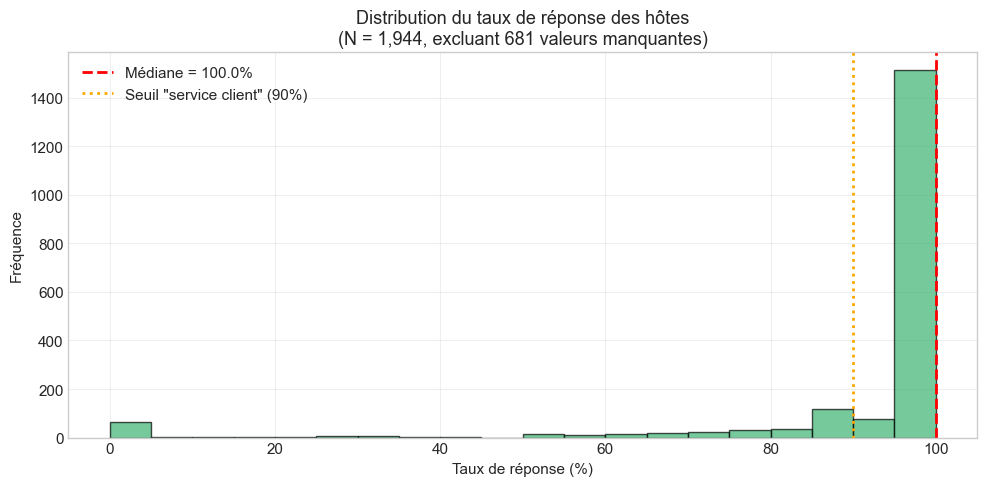


💡 Interprétation :
   Un taux de réponse élevé peut caractériser une gestion professionnelle.


In [14]:
print("\n\n┌─────────────────────────────────────────────────────────────┐")
print("│ VARIABLE : host_response_rate_num                          │")
print("│ Type : Quantitative continue (0 à 100%)                    │")
print("│ Signification : Taux de réponse de l'hôte                  │")
print("└─────────────────────────────────────────────────────────────┘")

# Gestion des -1
df_resp = df[df['host_response_rate_num'] >= 0]
missing_resp = (df['host_response_rate_num'] == -1).sum()
pct_missing_resp = 100 * missing_resp / len(df)

print(f"\n⚠️  Données manquantes (-1) : {missing_resp:,} ({pct_missing_resp:.1f}%)")
print(f"   Effectif analysable : {len(df_resp):,} annonces")

if len(df_resp) > 0:
    stats_resp = df_resp['host_response_rate_num'].describe()
    print(f"\n📈 Statistiques descriptives (hors -1) :")
    print(f"   Minimum : {stats_resp['min']:.1f}%")
    print(f"   Q1 : {stats_resp['25%']:.1f}%")
    print(f"   Médiane : {stats_resp['50%']:.1f}%")
    print(f"   Q3 : {stats_resp['75%']:.1f}%")
    print(f"   Maximum : {stats_resp['max']:.1f}%")
    print(f"   Moyenne : {stats_resp['mean']:.1f}%")
    
    # Hôtes très réactifs
    very_responsive = (df_resp['host_response_rate_num'] == 100).sum()
    pct_very_resp = 100 * very_responsive / len(df_resp)
    print(f"\n🏆 Hôtes à 100% de réponse : {very_responsive:,} ({pct_very_resp:.1f}%)")
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df_resp['host_response_rate_num'], bins=20, edgecolor='black', 
            alpha=0.7, color='mediumseagreen')
    ax.set_xlabel('Taux de réponse (%)')
    ax.set_ylabel('Fréquence')
    ax.set_title(f'Distribution du taux de réponse des hôtes\n(N = {len(df_resp):,}, excluant {missing_resp:,} valeurs manquantes)')
    ax.axvline(stats_resp['50%'], color='red', linestyle='--', 
               linewidth=2, label=f'Médiane = {stats_resp["50%"]:.1f}%')
    ax.axvline(90, color='orange', linestyle=':', 
               linewidth=2, label='Seuil "service client" (90%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('univarie_host_response_rate.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n💡 Interprétation :")
    print("   Un taux de réponse élevé peut caractériser une gestion professionnelle.")
else:
    print("\n⚠️  Toutes les valeurs sont manquantes : analyse impossible.")




┌─────────────────────────────────────────────────────────────┐
│ VARIABLE : room_type_code                                  │
│ Type : Catégorielle nominale (codes 0-3, -1)               │
│ Mapping : 0=Shared, 1=Private, 2=Entire home, 3=Hotel      │
└─────────────────────────────────────────────────────────────┘

📊 Répartition par type de logement :
   Code  2 - Logement entier           : 2,247 annonces ( 85.6%)
   Code  1 - Chambre privée            :   297 annonces ( 11.3%)
   Code  3 - Chambre d'hôtel           :    81 annonces (  3.1%)


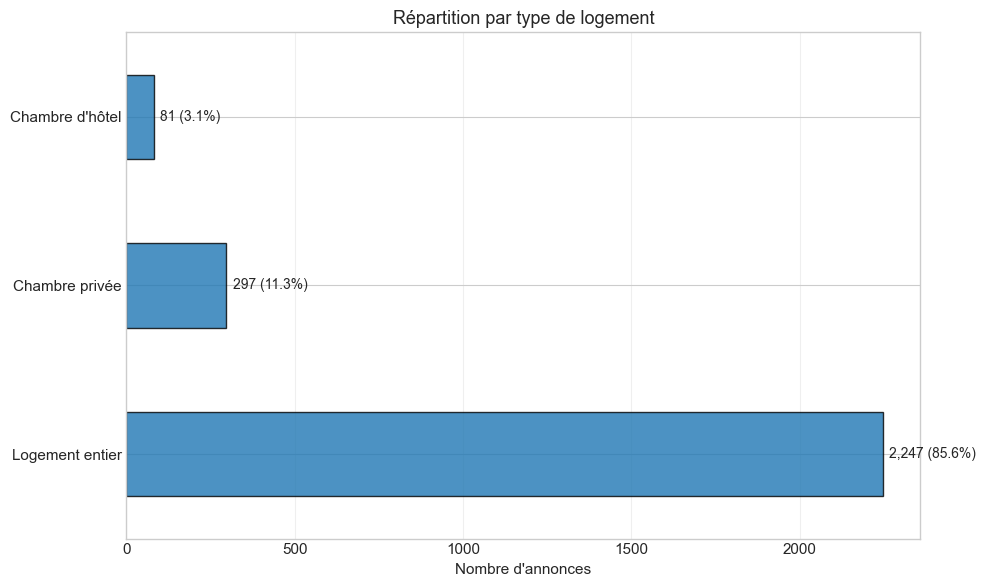


💡 Interprétation :
   Le type 'Logement entier' domine généralement dans les zones touristiques.
   Une forte proportion de ce type peut indiquer une offre orientée investissement.


In [15]:
print("\n\n┌─────────────────────────────────────────────────────────────┐")
print("│ VARIABLE : room_type_code                                  │")
print("│ Type : Catégorielle nominale (codes 0-3, -1)               │")
print("│ Mapping : 0=Shared, 1=Private, 2=Entire home, 3=Hotel      │")
print("└─────────────────────────────────────────────────────────────┘")

# Mapping des codes
room_type_labels = {
    -1: 'Inconnu',
    0: 'Chambre partagée',
    1: 'Chambre privée',
    2: 'Logement entier',
    3: 'Chambre d\'hôtel'
}

df['room_type_label'] = df['room_type_code'].map(room_type_labels)
room_dist = df['room_type_label'].value_counts()

print(f"\n📊 Répartition par type de logement :")
for label, count in room_dist.items():
    pct = 100 * count / len(df)
    code = [k for k, v in room_type_labels.items() if v == label][0]
    print(f"   Code {code:2d} - {label:25s} : {count:5,} annonces ({pct:5.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
colors_room = ['#d62728' if 'Inconnu' in x else '#1f77b4' for x in room_dist.index]
room_dist.plot(kind='barh', ax=ax, color=colors_room, edgecolor='black', alpha=0.8)
ax.set_xlabel('Nombre d\'annonces')
ax.set_ylabel('')
ax.set_title('Répartition par type de logement')
ax.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(room_dist):
    ax.text(v + 20, i, f'{v:,} ({100*v/len(df):.1f}%)', 
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig('univarie_room_type.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Interprétation :")
print("   Le type 'Logement entier' domine généralement dans les zones touristiques.")
print("   Une forte proportion de ce type peut indiquer une offre orientée investissement.")




┌─────────────────────────────────────────────────────────────┐
│ VARIABLE : host_response_time_code                         │
│ Type : Ordinale (codes 0-3, -1)                            │
│ Mapping : 0=1h, 1=quelques h, 2=1 jour, 3=plusieurs jours  │
└─────────────────────────────────────────────────────────────┘

📊 Répartition par temps de réponse (ordre : rapide → lent) :
   Code  0 - Dans l'heure         : 1,356 annonces ( 51.7%)
   Code  1 - Quelques heures      :   244 annonces (  9.3%)
   Code  2 - Dans la journée      :   255 annonces (  9.7%)
   Code  3 - Plusieurs jours      :    89 annonces (  3.4%)
   Code -1 - Inconnu              :   681 annonces ( 25.9%)


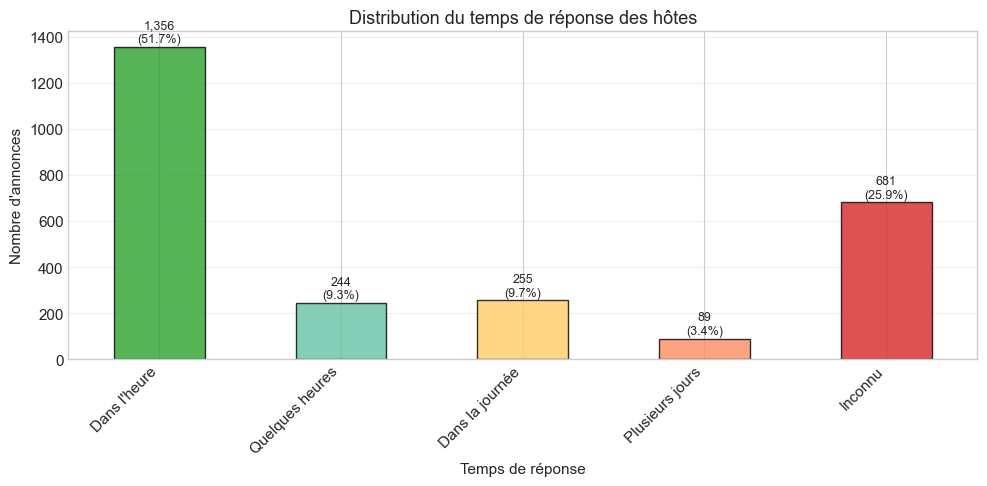


💡 Interprétation :
   Un temps de réponse court (codes 0-1) peut caractériser une gestion professionnelle
   ou un système automatisé type 'service client'.


In [16]:
print("\n\n┌─────────────────────────────────────────────────────────────┐")
print("│ VARIABLE : host_response_time_code                         │")
print("│ Type : Ordinale (codes 0-3, -1)                            │")
print("│ Mapping : 0=1h, 1=quelques h, 2=1 jour, 3=plusieurs jours  │")
print("└─────────────────────────────────────────────────────────────┘")

# Mapping des codes
response_time_labels = {
    -1: 'Inconnu',
    0: 'Dans l\'heure',
    1: 'Quelques heures',
    2: 'Dans la journée',
    3: 'Plusieurs jours'
}

df['response_time_label'] = df['host_response_time_code'].map(response_time_labels)
response_dist = df['response_time_label'].value_counts()

# Tri dans l'ordre logique
order = ['Dans l\'heure', 'Quelques heures', 'Dans la journée', 'Plusieurs jours', 'Inconnu']
response_dist = response_dist.reindex([x for x in order if x in response_dist.index])

print(f"\n📊 Répartition par temps de réponse (ordre : rapide → lent) :")
for label, count in response_dist.items():
    pct = 100 * count / len(df)
    code = [k for k, v in response_time_labels.items() if v == label][0]
    print(f"   Code {code:2d} - {label:20s} : {count:5,} annonces ({pct:5.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
colors_time = ['#2ca02c', '#66c2a5', '#ffcc66', '#fc8d62', '#d62728']
response_dist.plot(kind='bar', ax=ax, color=colors_time[:len(response_dist)], 
                   edgecolor='black', alpha=0.8)
ax.set_xlabel('Temps de réponse')
ax.set_ylabel('Nombre d\'annonces')
ax.set_title('Distribution du temps de réponse des hôtes')
ax.set_xticklabels(response_dist.index, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(response_dist):
    ax.text(i, v + 20, f'{v:,}\n({100*v/len(df):.1f}%)', 
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('univarie_response_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Interprétation :")
print("   Un temps de réponse court (codes 0-1) peut caractériser une gestion professionnelle")
print("   ou un système automatisé type 'service client'.")




┌─────────────────────────────────────────────────────────────┐
│ VARIABLE : standardization_score                           │
│ Type : Ordinale trichotomique (-1, 0, 1)                   │
│ Mapping : 1=Industrialisé, 0=Personnel, -1=Autre           │
└─────────────────────────────────────────────────────────────┘

📊 Répartition par niveau de standardisation :
   Code  1 - Appartement industrialisé      : 1,050 annonces ( 40.0%)
   Code  0 - Appartement personnel          :   792 annonces ( 30.2%)
   Code -1 - Autre/Erreur                   :   783 annonces ( 29.8%)

🎯 Analyse hors 'Autre/Erreur' (N = 1,842) :
   Industrialisé : 1,050 (57.0%)
   Personnel : 792 (43.0%)

   Hypothèse non validée au seuil 80% (atteint : 57.0%)


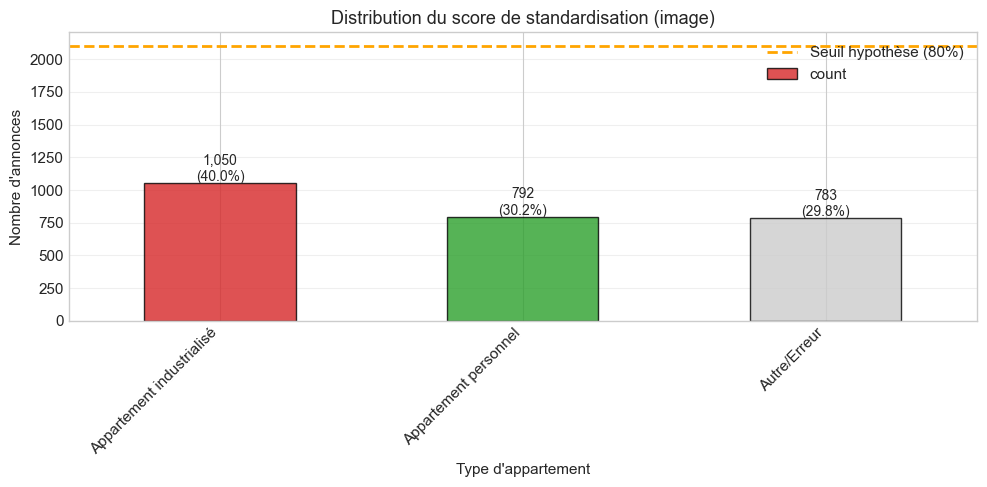


💡 Interprétation :
   Ce score mesure le degré de 'catalogue' détecté dans les photos.
   Un taux élevé d'industrialisation suggère une transformation en produit financier.


In [17]:
print("\n\n┌─────────────────────────────────────────────────────────────┐")
print("│ VARIABLE : standardization_score                           │")
print("│ Type : Ordinale trichotomique (-1, 0, 1)                   │")
print("│ Mapping : 1=Industrialisé, 0=Personnel, -1=Autre           │")
print("└─────────────────────────────────────────────────────────────┘")

# Mapping des codes
standard_labels = {
    -1: 'Autre/Erreur',
    0: 'Appartement personnel',
    1: 'Appartement industrialisé'
}

df['standard_label'] = df['standardization_score'].map(standard_labels)
standard_dist = df['standard_label'].value_counts()

# Tri dans l'ordre logique
order_std = ['Appartement industrialisé', 'Appartement personnel', 'Autre/Erreur']
standard_dist = standard_dist.reindex([x for x in order_std if x in standard_dist.index])

print(f"\n📊 Répartition par niveau de standardisation :")
for label, count in standard_dist.items():
    pct = 100 * count / len(df)
    code = [k for k, v in standard_labels.items() if v == label][0]
    print(f"   Code {code:2d} - {label:30s} : {count:5,} annonces ({pct:5.1f}%)")

# Calcul du ratio (excluant -1)
df_std_clean = df[df['standardization_score'] != -1]
if len(df_std_clean) > 0:
    industrialized = (df_std_clean['standardization_score'] == 1).sum()
    personal = (df_std_clean['standardization_score'] == 0).sum()
    ratio_industrialized = 100 * industrialized / len(df_std_clean)
    
    print(f"\n🎯 Analyse hors 'Autre/Erreur' (N = {len(df_std_clean):,}) :")
    print(f"   Industrialisé : {industrialized:,} ({ratio_industrialized:.1f}%)")
    print(f"   Personnel : {personal:,} ({100-ratio_industrialized:.1f}%)")
    
    if ratio_industrialized >= 80:
        print(f"\n🚨 ALERTE : {ratio_industrialized:.1f}% ≥ 80% → Hypothèse STANDARDISATION VALIDÉE")
    else:
        print(f"\n   Hypothèse non validée au seuil 80% (atteint : {ratio_industrialized:.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
colors_std = ['#d62728', '#2ca02c', '#cccccc']
standard_dist.plot(kind='bar', ax=ax, color=colors_std[:len(standard_dist)], 
                   edgecolor='black', alpha=0.8)
ax.set_xlabel('Type d\'appartement')
ax.set_ylabel('Nombre d\'annonces')
ax.set_title('Distribution du score de standardisation (image)')
ax.set_xticklabels(standard_dist.index, rotation=45, ha='right')
ax.axhline(0.8 * len(df), color='orange', linestyle='--', 
           linewidth=2, label='Seuil hypothèse (80%)')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

for i, v in enumerate(standard_dist):
    ax.text(i, v + 20, f'{v:,}\n({100*v/len(df):.1f}%)', 
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('univarie_standardization_score.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Interprétation :")
print("   Ce score mesure le degré de 'catalogue' détecté dans les photos.")
print("   Un taux élevé d'industrialisation suggère une transformation en produit financier.")




┌─────────────────────────────────────────────────────────────┐
│ VARIABLE : neighborhood_impact_score                       │
│ Type : Ordinale trichotomique (-1, 0, 1)                   │
│ Mapping : 1=Hôtélisé, 0=Voisinage naturel, -1=Autre        │
└─────────────────────────────────────────────────────────────┘

📊 Répartition par impact voisinage (texte) :
   Code  1 - Hôtélisé                  : 1,004 annonces ( 38.2%)
   Code  0 - Voisinage naturel         :   799 annonces ( 30.4%)
   Code -1 - Autre/Ambigu              :   822 annonces ( 31.3%)

🎯 Analyse hors 'Autre/Ambigu' (N = 1,803) :
   Hôtélisé : 1,004 (55.7%)
   Naturel : 799 (44.3%)

🚨 ALERTE : 55.7% > 50% → Hypothèse DÉSHUMANISATION VALIDÉE


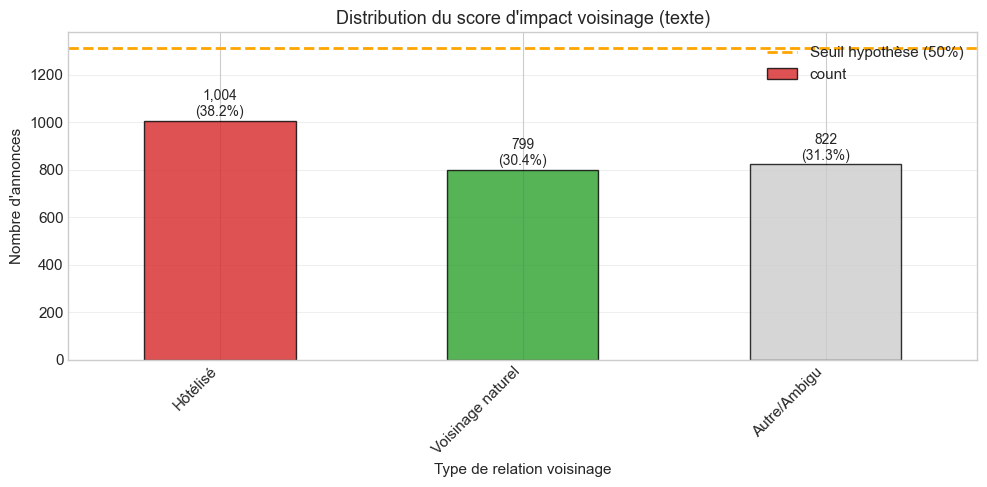


💡 Interprétation :
   Ce score détecte le vocabulaire 'hôtelier' vs 'humain' dans les descriptions.
   Un taux élevé d'hôtélisation suggère une rupture du lien social.


In [18]:

print("\n\n┌─────────────────────────────────────────────────────────────┐")
print("│ VARIABLE : neighborhood_impact_score                       │")
print("│ Type : Ordinale trichotomique (-1, 0, 1)                   │")
print("│ Mapping : 1=Hôtélisé, 0=Voisinage naturel, -1=Autre        │")
print("└─────────────────────────────────────────────────────────────┘")

# Mapping des codes
neighbor_labels = {
    -1: 'Autre/Ambigu',
    0: 'Voisinage naturel',
    1: 'Hôtélisé'
}

df['neighbor_label'] = df['neighborhood_impact_score'].map(neighbor_labels)
neighbor_dist = df['neighbor_label'].value_counts()

# Tri dans l'ordre logique
order_neigh = ['Hôtélisé', 'Voisinage naturel', 'Autre/Ambigu']
neighbor_dist = neighbor_dist.reindex([x for x in order_neigh if x in neighbor_dist.index])

print(f"\n📊 Répartition par impact voisinage (texte) :")
for label, count in neighbor_dist.items():
    pct = 100 * count / len(df)
    code = [k for k, v in neighbor_labels.items() if v == label][0]
    print(f"   Code {code:2d} - {label:25s} : {count:5,} annonces ({pct:5.1f}%)")

# Calcul du ratio (excluant -1)
df_neigh_clean = df[df['neighborhood_impact_score'] != -1]
if len(df_neigh_clean) > 0:
    hotelized = (df_neigh_clean['neighborhood_impact_score'] == 1).sum()
    natural = (df_neigh_clean['neighborhood_impact_score'] == 0).sum()
    ratio_hotelized = 100 * hotelized / len(df_neigh_clean)
    
    print(f"\n🎯 Analyse hors 'Autre/Ambigu' (N = {len(df_neigh_clean):,}) :")
    print(f"   Hôtélisé : {hotelized:,} ({ratio_hotelized:.1f}%)")
    print(f"   Naturel : {natural:,} ({100-ratio_hotelized:.1f}%)")
    
    if ratio_hotelized > 50:
        print(f"\n🚨 ALERTE : {ratio_hotelized:.1f}% > 50% → Hypothèse DÉSHUMANISATION VALIDÉE")
    else:
        print(f"\n   Hypothèse non validée au seuil 50% (atteint : {ratio_hotelized:.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
colors_neigh = ['#d62728', '#2ca02c', '#cccccc']
neighbor_dist.plot(kind='bar', ax=ax, color=colors_neigh[:len(neighbor_dist)], 
                   edgecolor='black', alpha=0.8)
ax.set_xlabel('Type de relation voisinage')
ax.set_ylabel('Nombre d\'annonces')
ax.set_title('Distribution du score d\'impact voisinage (texte)')
ax.set_xticklabels(neighbor_dist.index, rotation=45, ha='right')
ax.axhline(0.5 * len(df), color='orange', linestyle='--', 
           linewidth=2, label='Seuil hypothèse (50%)')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

for i, v in enumerate(neighbor_dist):
    ax.text(i, v + 20, f'{v:,}\n({100*v/len(df):.1f}%)', 
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('univarie_neighborhood_score.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Interprétation :")
print("   Ce score détecte le vocabulaire 'hôtelier' vs 'humain' dans les descriptions.")
print("   Un taux élevé d'hôtélisation suggère une rupture du lien social.")

In [19]:
print("\n\n" + "=" * 80)
print("📋 SYNTHÈSE DE LA DESCRIPTION UNIVARIÉE")
print("=" * 80)

summary_data = {
    'Variable': [
        'id',
        'calculated_host_listings_count',
        'availability_365',
        'host_response_rate_num',
        'room_type_code',
        'host_response_time_code',
        'standardization_score',
        'neighborhood_impact_score'
    ],
    'Type': [
        'Identifiant',
        'Quantitative',
        'Quantitative',
        'Quantitative',
        'Nominale',
        'Ordinale',
        'Ordinale trichotomique',
        'Ordinale trichotomique'
    ],
    'N_valide': [
        len(df),
        len(df),
        len(df),
        len(df[df['host_response_rate_num'] >= 0]),
        len(df),
        len(df),
        len(df),
        len(df)
    ],
    'N_manquant_-1': [
        0,
        0,
        0,
        (df['host_response_rate_num'] == -1).sum(),
        (df['room_type_code'] == -1).sum(),
        (df['host_response_time_code'] == -1).sum(),
        (df['standardization_score'] == -1).sum(),
        (df['neighborhood_impact_score'] == -1).sum()
    ],
    'Observations_clés': [
        'Identifiant unique',
        f'Médiane={stats_host["50%"]:.0f}, Max={stats_host["max"]:.0f}',
        f'Médiane={stats_avail["50%"]:.0f}j, >300j={100*(df["availability_365"]>300).sum()/len(df):.1f}%',
        f'Médiane={stats_resp["50%"]:.1f}%' if len(df_resp) > 0 else 'Toutes manquantes',
        f'Logement entier={100*room_dist.get("Logement entier", 0)/len(df):.1f}%',
        f'Dans l\'heure={100*response_dist.get("Dans l\'heure", 0)/len(df):.1f}%',
        f'Industrialisé={100*(df["standardization_score"]==1).sum()/len(df):.1f}%',
        f'Hôtélisé={100*(df["neighborhood_impact_score"]==1).sum()/len(df):.1f}%'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "=" * 80)
print("✓ BLOC B TERMINÉ : Description univariée complète")
print(f"  Graphiques générés : 8 fichiers PNG sauvegardés")
print(f"  DataFrame df prêt pour analyses bivariées (Bloc C)")
print("=" * 80)



📋 SYNTHÈSE DE LA DESCRIPTION UNIVARIÉE

                      Variable                   Type  N_valide  N_manquant_-1         Observations_clés
                            id            Identifiant      2625              0        Identifiant unique
calculated_host_listings_count           Quantitative      2625              0        Médiane=3, Max=816
              availability_365           Quantitative      2625              0 Médiane=183j, >300j=28.8%
        host_response_rate_num           Quantitative      1944            681            Médiane=100.0%
                room_type_code               Nominale      2625              0     Logement entier=85.6%
       host_response_time_code               Ordinale      2625            681        Dans l'heure=51.7%
         standardization_score Ordinale trichotomique      2625            783       Industrialisé=40.0%
     neighborhood_impact_score Ordinale trichotomique      2625            822            Hôtélisé=38.2%

✓ BLOC B TER

# BLOC C : ANALYSES BIVARIÉES ET CROISEMENTS
Objectif : Exécuter la feuille de route du Bloc A pour répondre aux problématiques de la mairie.
Note : Les liaisons observées ici sont des corrélations et non des preuves de causalité.



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Q1 : Les appartements sont-ils massivement 'industrialisés' ? ┃
┃ [HYPOTHÈSE STANDARDISATION]                                    ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

📊 RÉSULTATS (N valide = 1,842, excluant 783 valeurs -1) :
   Appartements industrialisés (score=1) : 1,050 (57.0%)
   Appartements personnels (score=0)     : 792 (43.0%)

🎯 TEST D'HYPOTHÈSE :
   H0 : Le quartier n'est PAS massivement transformé en produit financier
   H1 : ≥80% des annonces sont industrialisées
   Seuil critique : 80.0%
   Taux observé : 57.0%

   ❌ HYPOTHÈSE NON VALIDÉE au seuil 80.0%
      → Taux réel : 57.0%
      → Nuance nécessaire : standardisation présente mais non écrasante


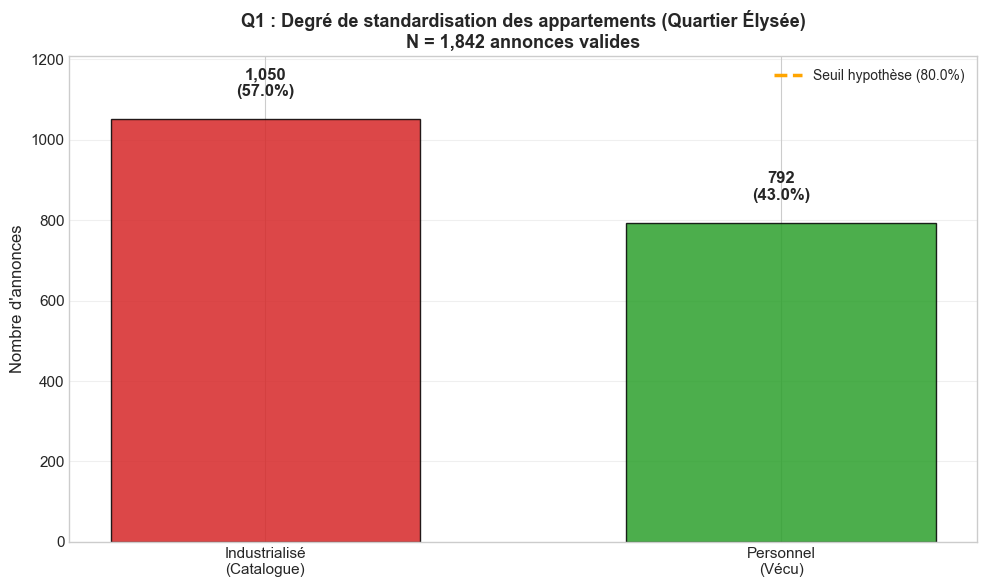


💾 Graphique sauvegardé : q1_standardisation_repartition.png

📝 INTERPRÉTATION MÉTIER :
   • Ce score provient de l'analyse IA des photos d'annonces
   • 'Industrialisé' = décoration Ikea, murs blancs, absence d'objets personnels
   • 'Personnel' = livres, photos, traces de vie quotidienne
   • Un taux élevé d'industrialisation suggère que les logements
     ne sont plus des habitats partagés mais des produits optimisés pour le rendement

⚠️  LIMITES :
   • L'analyse ne prouve pas QUI possède (investisseur vs particulier)
   • Facteur commun possible : quartier touristique → décoration neutre par choix marketing
   • Données manquantes (-1) : si concentrées sur un type de bien, biais possible


In [20]:
print("\n\n┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓")
print("┃ Q1 : Les appartements sont-ils massivement 'industrialisés' ? ┃")
print("┃ [HYPOTHÈSE STANDARDISATION]                                    ┃")
print("┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛")

# Calcul du taux (hors -1)
df_std = df[df['standardization_score'] != -1].copy()
n_industrialized = (df_std['standardization_score'] == 1).sum()
n_personal = (df_std['standardization_score'] == 0).sum()
n_total_valid = len(df_std)

pct_industrialized = 100 * n_industrialized / n_total_valid if n_total_valid > 0 else 0
pct_personal = 100 * n_personal / n_total_valid if n_total_valid > 0 else 0

print(f"\n📊 RÉSULTATS (N valide = {n_total_valid:,}, excluant {(df['standardization_score']==-1).sum():,} valeurs -1) :")
print(f"   Appartements industrialisés (score=1) : {n_industrialized:,} ({pct_industrialized:.1f}%)")
print(f"   Appartements personnels (score=0)     : {n_personal:,} ({pct_personal:.1f}%)")

# Test de l'hypothèse
SEUIL_STANDARDISATION = 80.0
print(f"\n🎯 TEST D'HYPOTHÈSE :")
print(f"   H0 : Le quartier n'est PAS massivement transformé en produit financier")
print(f"   H1 : ≥80% des annonces sont industrialisées")
print(f"   Seuil critique : {SEUIL_STANDARDISATION}%")
print(f"   Taux observé : {pct_industrialized:.1f}%")

if pct_industrialized >= SEUIL_STANDARDISATION:
    print(f"\n   ✅ HYPOTHÈSE VALIDÉE : {pct_industrialized:.1f}% ≥ {SEUIL_STANDARDISATION}%")
    print(f"      → La majorité écrasante des logements présentent un style 'catalogue'")
    print(f"      → Compatible avec une logique de produit financier standardisé")
else:
    print(f"\n   ❌ HYPOTHÈSE NON VALIDÉE au seuil {SEUIL_STANDARDISATION}%")
    print(f"      → Taux réel : {pct_industrialized:.1f}%")
    print(f"      → Nuance nécessaire : standardisation présente mais non écrasante")

# Graphique amélioré
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Industrialisé\n(Catalogue)', 'Personnel\n(Vécu)']
values = [n_industrialized, n_personal]
colors = ['#d62728', '#2ca02c']

bars = ax.bar(categories, values, color=colors, edgecolor='black', alpha=0.85, width=0.6)

# Ligne seuil
threshold_value = SEUIL_STANDARDISATION * n_total_valid / 100
ax.axhline(threshold_value, color='orange', linestyle='--', linewidth=2.5, 
           label=f'Seuil hypothèse ({SEUIL_STANDARDISATION}%)', zorder=0)

# Annotations
for i, (bar, val) in enumerate(zip(bars, values)):
    height = bar.get_height()
    pct = 100 * val / n_total_valid
    ax.text(bar.get_x() + bar.get_width()/2, height + 50,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Nombre d\'annonces', fontsize=12)
ax.set_title(f'Q1 : Degré de standardisation des appartements (Quartier Élysée)\nN = {n_total_valid:,} annonces valides',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('q1_standardisation_repartition.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Graphique sauvegardé : q1_standardisation_repartition.png")

print("\n📝 INTERPRÉTATION MÉTIER :")
print("   • Ce score provient de l'analyse IA des photos d'annonces")
print("   • 'Industrialisé' = décoration Ikea, murs blancs, absence d'objets personnels")
print("   • 'Personnel' = livres, photos, traces de vie quotidienne")
print("   • Un taux élevé d'industrialisation suggère que les logements")
print("     ne sont plus des habitats partagés mais des produits optimisés pour le rendement")

print("\n⚠️  LIMITES :")
print("   • L'analyse ne prouve pas QUI possède (investisseur vs particulier)")
print("   • Facteur commun possible : quartier touristique → décoration neutre par choix marketing")
print("   • Données manquantes (-1) : si concentrées sur un type de bien, biais possible")



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Q2 : Les logements entiers sont-ils plus standardisés ?       ┃
┃ [STANDARDISATION × VOLUME - Clivage investisseur]              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

📊 TABLEAU CROISÉ (effectifs) - N = 1,783 :
std_label        Industrialisé  Personnel   All
room_label                                     
Chambre privée             126         85   211
Logement entier            894        678  1572
All                       1020        763  1783

📊 TABLEAU CROISÉ (% ligne) :
std_label        Industrialisé  Personnel
room_label                               
Chambre privée            59.7       40.3
Logement entier           56.9       43.1

📈 TEST DU KHI-DEUX (χ²) :
   Statistique χ² = 0.50
   p-value = 0.4775
   Degrés de liberté = 1
   ❌ Pas d'association significative (p ≥ 0.05)


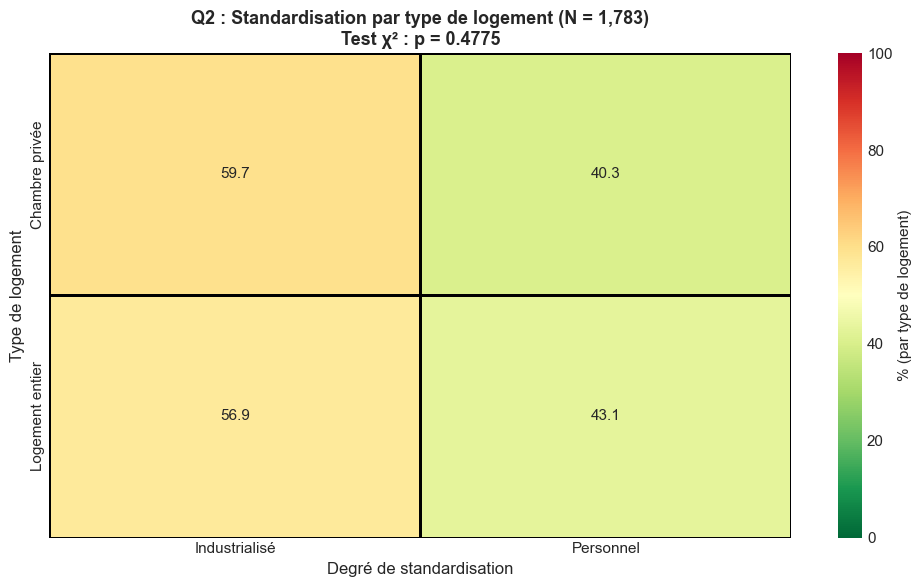


💾 Graphique sauvegardé : q2_standardisation_par_type.png

📝 INTERPRÉTATION MÉTIER :
   • Logements entiers industrialisés : 56.9%
   • Chambres privées industrialisées : 59.7%
   ⚠️  Écart faible (2.8 points)

⚠️  LIMITES :
   • 'Logement entier' ≠ preuve d'achat par investisseur (peut être résidence principale louée)
   • Facteur commun : plateforme Airbnb recommande la décoration neutre → même conseil pour tous
   • Absence de données : date d'achat, statut propriétaire (particulier/société)


In [21]:
print("\n\n┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓")
print("┃ Q2 : Les logements entiers sont-ils plus standardisés ?       ┃")
print("┃ [STANDARDISATION × VOLUME - Clivage investisseur]              ┃")
print("┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛")

# Filtrage : scores valides + types principaux
df_q2 = df[(df['standardization_score'] != -1) & 
           (df['room_type_code'].isin([1, 2]))].copy()

# Mapping lisible
room_map = {1: 'Chambre privée', 2: 'Logement entier'}
df_q2['room_label'] = df_q2['room_type_code'].map(room_map)
df_q2['std_label'] = df_q2['standardization_score'].map({0: 'Personnel', 1: 'Industrialisé'})

# Tableau croisé
crosstab = pd.crosstab(df_q2['room_label'], df_q2['std_label'], margins=True)
crosstab_pct = pd.crosstab(df_q2['room_label'], df_q2['std_label'], normalize='index') * 100

print(f"\n📊 TABLEAU CROISÉ (effectifs) - N = {len(df_q2):,} :")
print(crosstab)

print(f"\n📊 TABLEAU CROISÉ (% ligne) :")
print(crosstab_pct.round(1))

# Test du khi-deux
chi2, p_value, dof, expected = chi2_contingency(crosstab.iloc[:-1, :-1])
print(f"\n📈 TEST DU KHI-DEUX (χ²) :")
print(f"   Statistique χ² = {chi2:.2f}")
print(f"   p-value = {p_value:.4f}")
print(f"   Degrés de liberté = {dof}")

if p_value < 0.05:
    print(f"   ✅ Association significative (p < 0.05)")
    print(f"      → Le type de logement et la standardisation ne sont PAS indépendants")
else:
    print(f"   ❌ Pas d'association significative (p ≥ 0.05)")

# Graphique : Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

# Matrice pour heatmap (% ligne)
heatmap_data = crosstab_pct.drop('All', errors='ignore')
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=2, linecolor='black', cbar_kws={'label': '% (par type de logement)'},
            vmin=0, vmax=100, ax=ax)

ax.set_xlabel('Degré de standardisation', fontsize=12)
ax.set_ylabel('Type de logement', fontsize=12)
ax.set_title(f'Q2 : Standardisation par type de logement (N = {len(df_q2):,})\nTest χ² : p = {p_value:.4f}',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('q2_standardisation_par_type.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Graphique sauvegardé : q2_standardisation_par_type.png")

# Analyse comparative
pct_entire_industrialized = crosstab_pct.loc['Logement entier', 'Industrialisé'] if 'Logement entier' in crosstab_pct.index else 0
pct_private_industrialized = crosstab_pct.loc['Chambre privée', 'Industrialisé'] if 'Chambre privée' in crosstab_pct.index else 0

print("\n📝 INTERPRÉTATION MÉTIER :")
print(f"   • Logements entiers industrialisés : {pct_entire_industrialized:.1f}%")
print(f"   • Chambres privées industrialisées : {pct_private_industrialized:.1f}%")

if pct_entire_industrialized > pct_private_industrialized + 10:
    print(f"   ✅ ÉCART NOTABLE : +{pct_entire_industrialized - pct_private_industrialized:.1f} points")
    print(f"      → Les logements entiers (achetables par investisseurs) sont effectivement")
    print(f"        plus standardisés que les chambres (souvent chez l'habitant)")
    print(f"      → Compatible avec l'hypothèse : achat immobilier → optimisation catalogue")
else:
    print(f"   ⚠️  Écart faible ({abs(pct_entire_industrialized - pct_private_industrialized):.1f} points)")

print("\n⚠️  LIMITES :")
print("   • 'Logement entier' ≠ preuve d'achat par investisseur (peut être résidence principale louée)")
print("   • Facteur commun : plateforme Airbnb recommande la décoration neutre → même conseil pour tous")
print("   • Absence de données : date d'achat, statut propriétaire (particulier/société)")




┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Q3 : Les descriptions révèlent-elles une logique 'hôtelière' ? ┃
┃ [HYPOTHÈSE DÉSHUMANISATION]                                    ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

📊 RÉSULTATS (N valide = 1,803, excluant 822 valeurs -1) :
   Descriptions 'hôtelisées' (score=1) : 1,004 (55.7%)
   Descriptions 'naturelles' (score=0)  : 799 (44.3%)

🎯 TEST D'HYPOTHÈSE :
   H0 : Le lien social n'est PAS brisé (majorité de textes 'humains')
   H1 : >50% des descriptions sont 'hôtelisées'
   Seuil critique : 50.0%
   Taux observé : 55.7%

   ✅ HYPOTHÈSE VALIDÉE : 55.7% > 50.0%
      → La majorité des textes adoptent un vocabulaire 'service client'
      → Compatible avec une rupture du lien social


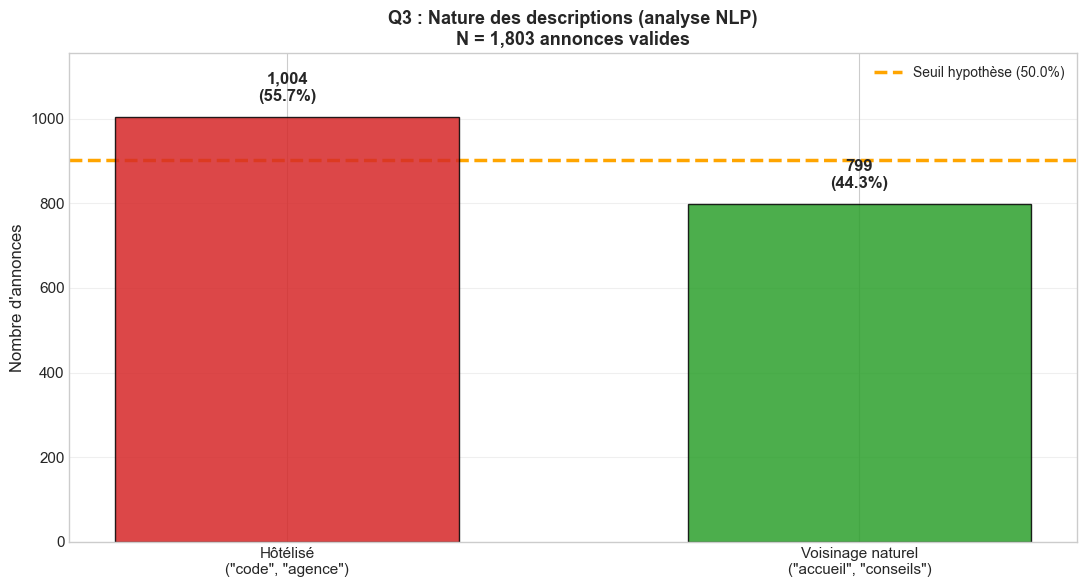


💾 Graphique sauvegardé : q3_deshumanisation_textes.png

📝 INTERPRÉTATION MÉTIER :
   • Ce score provient de l'analyse NLP des descriptions textuelles
   • 'Hôtélisé' = vocabulaire type 'boîte à clés', 'code d'accès', 'géré par agence'
   • 'Naturel' = vocabulaire type 'je vous accueille', 'conseils de voisin', 'échanges'
   • Un taux élevé d'hôtélisation suggère une absence physique de l'hôte
     et une gestion à distance, réduisant les interactions humaines

⚠️  LIMITES :
   • Un texte 'hôtélisé' ne prouve pas l'hostilité des voisins (peut être neutre)
   • Facteur commun : professionnalisation → templates de descriptions standardisées
   • Biais possible : algorithme NLP entraîné sur corpus spécifique


In [22]:
print("\n\n┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓")
print("┃ Q3 : Les descriptions révèlent-elles une logique 'hôtelière' ? ┃")
print("┃ [HYPOTHÈSE DÉSHUMANISATION]                                    ┃")
print("┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛")

# Calcul du taux (hors -1)
df_neigh = df[df['neighborhood_impact_score'] != -1].copy()
n_hotelized = (df_neigh['neighborhood_impact_score'] == 1).sum()
n_natural = (df_neigh['neighborhood_impact_score'] == 0).sum()
n_total_neigh = len(df_neigh)

pct_hotelized = 100 * n_hotelized / n_total_neigh if n_total_neigh > 0 else 0
pct_natural = 100 * n_natural / n_total_neigh if n_total_neigh > 0 else 0

print(f"\n📊 RÉSULTATS (N valide = {n_total_neigh:,}, excluant {(df['neighborhood_impact_score']==-1).sum():,} valeurs -1) :")
print(f"   Descriptions 'hôtelisées' (score=1) : {n_hotelized:,} ({pct_hotelized:.1f}%)")
print(f"   Descriptions 'naturelles' (score=0)  : {n_natural:,} ({pct_natural:.1f}%)")

# Test de l'hypothèse
SEUIL_DESHUMANISATION = 50.0
print(f"\n🎯 TEST D'HYPOTHÈSE :")
print(f"   H0 : Le lien social n'est PAS brisé (majorité de textes 'humains')")
print(f"   H1 : >50% des descriptions sont 'hôtelisées'")
print(f"   Seuil critique : {SEUIL_DESHUMANISATION}%")
print(f"   Taux observé : {pct_hotelized:.1f}%")

if pct_hotelized > SEUIL_DESHUMANISATION:
    print(f"\n   ✅ HYPOTHÈSE VALIDÉE : {pct_hotelized:.1f}% > {SEUIL_DESHUMANISATION}%")
    print(f"      → La majorité des textes adoptent un vocabulaire 'service client'")
    print(f"      → Compatible avec une rupture du lien social")
else:
    print(f"\n   ❌ HYPOTHÈSE NON VALIDÉE au seuil {SEUIL_DESHUMANISATION}%")
    print(f"      → Taux réel : {pct_hotelized:.1f}%")
    print(f"      → Le lien humain reste présent dans les descriptions")

# Graphique
fig, ax = plt.subplots(figsize=(11, 6))

categories = ['Hôtélisé\n("code", "agence")', 'Voisinage naturel\n("accueil", "conseils")']
values = [n_hotelized, n_natural]
colors = ['#d62728', '#2ca02c']

bars = ax.bar(categories, values, color=colors, edgecolor='black', alpha=0.85, width=0.6)

# Ligne seuil
threshold_value = SEUIL_DESHUMANISATION * n_total_neigh / 100
ax.axhline(threshold_value, color='orange', linestyle='--', linewidth=2.5, 
           label=f'Seuil hypothèse ({SEUIL_DESHUMANISATION}%)', zorder=0)

# Annotations
for i, (bar, val) in enumerate(zip(bars, values)):
    height = bar.get_height()
    pct = 100 * val / n_total_neigh
    ax.text(bar.get_x() + bar.get_width()/2, height + 30,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Nombre d\'annonces', fontsize=12)
ax.set_title(f'Q3 : Nature des descriptions (analyse NLP)\nN = {n_total_neigh:,} annonces valides',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('q3_deshumanisation_textes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Graphique sauvegardé : q3_deshumanisation_textes.png")

print("\n📝 INTERPRÉTATION MÉTIER :")
print("   • Ce score provient de l'analyse NLP des descriptions textuelles")
print("   • 'Hôtélisé' = vocabulaire type 'boîte à clés', 'code d'accès', 'géré par agence'")
print("   • 'Naturel' = vocabulaire type 'je vous accueille', 'conseils de voisin', 'échanges'")
print("   • Un taux élevé d'hôtélisation suggère une absence physique de l'hôte")
print("     et une gestion à distance, réduisant les interactions humaines")

print("\n⚠️  LIMITES :")
print("   • Un texte 'hôtélisé' ne prouve pas l'hostilité des voisins (peut être neutre)")
print("   • Facteur commun : professionnalisation → templates de descriptions standardisées")
print("   • Biais possible : algorithme NLP entraîné sur corpus spécifique")



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Q4 : Une minorité contrôle-t-elle la majorité de l'offre ?    ┃
┃ [HYPOTHÈSE MACHINE À CASH - Concentration]                     ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

📊 VUE D'ENSEMBLE :
   Nombre d'hôtes uniques : 2,625
   Nombre total d'annonces : 136,946
   Moyenne annonces/hôte : 52.17

📈 COEFFICIENT DE GINI : 0.851
   (0 = égalité parfaite, 1 = concentration maximale)

🎯 CONCENTRATION (Top 5% des hôtes) :
   Les 5% d'hôtes avec le plus d'annonces contrôlent : 41.8% de l'offre

🎯 TEST D'HYPOTHÈSE :
   H1 : Top 5% contrôle ≥60.0% de l'offre
   Taux observé : 41.8%

   ⚠️  HYPOTHÈSE NON VALIDÉE au seuil 60.0%
      → Concentration existante (41.8%) mais moins extrême


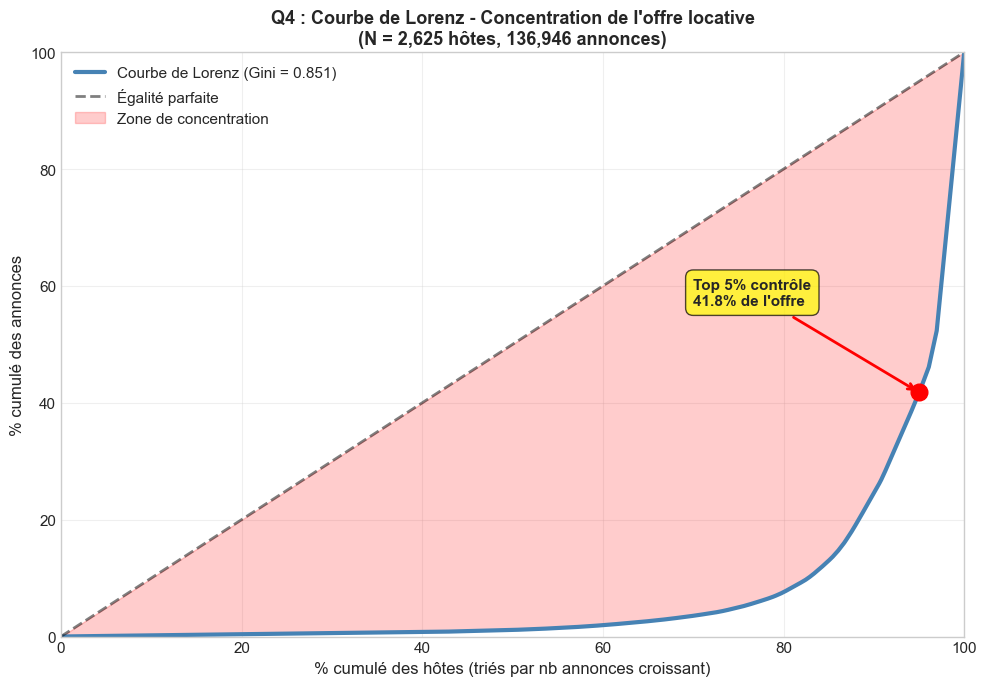


💾 Graphique sauvegardé : q4_concentration_lorenz.png

📊 RÉPARTITION MONO vs MULTI-ANNONCES :
   Mono-annonce (=1)      : 1,101 annonces ( 41.9%)
   Multi-annonces (2-10)  :   708 annonces ( 27.0%)
   Multi-annonces (>10)   :   816 annonces ( 31.1%)

📝 INTERPRÉTATION MÉTIER :
   • Gini = 0.851 indique une inégalité forte
   • 41.8% de l'offre contrôlée par 5% d'hôtes suggère :
     - Présence d'acteurs professionnels avec portefeuilles importants
     - Marginalisation des particuliers mono-annonce
   • Compatible avec l'hypothèse : 'machine à cash' pilotée par minorité

⚠️  LIMITES :
   • Absence de données prix → impossible de calculer REVENUS concentrés
   • 'Nombre d'annonces' = proxy du volume, pas du chiffre d'affaires
   • Facteur commun : quartier touristique attire naturellement investisseurs
   • Pas de distinction juridique : particulier vs société professionnelle


In [23]:
print("\n\n┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓")
print("┃ Q4 : Une minorité contrôle-t-elle la majorité de l'offre ?    ┃")
print("┃ [HYPOTHÈSE MACHINE À CASH - Concentration]                     ┃")
print("┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛")

# Données par hôte unique
host_counts = df.groupby('calculated_host_listings_count').size().reset_index(name='n_hosts')
# Chaque ligne = un nombre d'annonces, combien d'hôtes ont ce nombre

# Reconstruction : liste de tous les comptes d'hôtes
all_hosts_listings = []
for _, row in host_counts.iterrows():
    all_hosts_listings.extend([row['calculated_host_listings_count']] * row['n_hosts'])

all_hosts_listings = np.array(all_hosts_listings)
n_hosts_total = len(all_hosts_listings)
n_listings_total = all_hosts_listings.sum()

print(f"\n📊 VUE D'ENSEMBLE :")
print(f"   Nombre d'hôtes uniques : {n_hosts_total:,}")
print(f"   Nombre total d'annonces : {n_listings_total:,}")
print(f"   Moyenne annonces/hôte : {n_listings_total/n_hosts_total:.2f}")

# Tri croissant + calcul cumulatif
sorted_listings = np.sort(all_hosts_listings)
cumsum_hosts_pct = 100 * np.arange(1, len(sorted_listings)+1) / len(sorted_listings)
cumsum_listings_pct = 100 * np.cumsum(sorted_listings) / sorted_listings.sum()

# Calcul Gini - Utilisation de np.trapezoid (Nouveau standard NumPy 2.0)
gini = 1 - 2 * np.trapezoid(cumsum_listings_pct / 100, cumsum_hosts_pct / 100)

print(f"\n📈 COEFFICIENT DE GINI : {gini:.3f}")
print(f"   (0 = égalité parfaite, 1 = concentration maximale)")

# Top 5% des hôtes
threshold_95 = np.percentile(cumsum_hosts_pct, 95)
idx_95 = np.searchsorted(cumsum_hosts_pct, threshold_95)
pct_listings_top5 = cumsum_listings_pct[idx_95] if idx_95 < len(cumsum_listings_pct) else cumsum_listings_pct[-1]

print(f"\n🎯 CONCENTRATION (Top 5% des hôtes) :")
print(f"   Les 5% d'hôtes avec le plus d'annonces contrôlent : {pct_listings_top5:.1f}% de l'offre")

SEUIL_CONCENTRATION = 60.0
print(f"\n🎯 TEST D'HYPOTHÈSE :")
print(f"   H1 : Top 5% contrôle ≥{SEUIL_CONCENTRATION}% de l'offre")
print(f"   Taux observé : {pct_listings_top5:.1f}%")

if pct_listings_top5 >= SEUIL_CONCENTRATION:
    print(f"\n   ✅ HYPOTHÈSE VALIDÉE : {pct_listings_top5:.1f}% ≥ {SEUIL_CONCENTRATION}%")
    print(f"      → Concentration extrême de l'offre entre peu d'acteurs")
    print(f"      → Compatible avec une logique industrielle pilotée par minorité")
else:
    print(f"\n   ⚠️  HYPOTHÈSE NON VALIDÉE au seuil {SEUIL_CONCENTRATION}%")
    print(f"      → Concentration existante ({pct_listings_top5:.1f}%) mais moins extrême")

# Graphique : Courbe de Lorenz
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(cumsum_hosts_pct, cumsum_listings_pct, linewidth=3, color='steelblue', 
        label=f'Courbe de Lorenz (Gini = {gini:.3f})')
ax.plot([0, 100], [0, 100], 'k--', linewidth=2, alpha=0.5, label='Égalité parfaite')

# Zone de concentration
ax.fill_between(cumsum_hosts_pct, cumsum_listings_pct, 
                np.linspace(0, 100, len(cumsum_hosts_pct)),
                alpha=0.2, color='red', label='Zone de concentration')

# Marqueur Top 5%
ax.plot(95, pct_listings_top5, 'ro', markersize=12, zorder=5)
ax.annotate(f'Top 5% contrôle\n{pct_listings_top5:.1f}% de l\'offre',
            xy=(95, pct_listings_top5), xytext=(70, pct_listings_top5 + 15),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=2, color='red'),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_xlabel('% cumulé des hôtes (triés par nb annonces croissant)', fontsize=12)
ax.set_ylabel('% cumulé des annonces', fontsize=12)
ax.set_title(f'Q4 : Courbe de Lorenz - Concentration de l\'offre locative\n(N = {n_hosts_total:,} hôtes, {n_listings_total:,} annonces)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('q4_concentration_lorenz.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Graphique sauvegardé : q4_concentration_lorenz.png")

# Tableau complémentaire
print(f"\n📊 RÉPARTITION MONO vs MULTI-ANNONCES :")
mono = (df['calculated_host_listings_count'] == 1).sum()
multi_2_10 = ((df['calculated_host_listings_count'] > 1) & (df['calculated_host_listings_count'] <= 10)).sum()
multi_sup10 = (df['calculated_host_listings_count'] > 10).sum()

print(f"   Mono-annonce (=1)      : {mono:5,} annonces ({100*mono/len(df):5.1f}%)")
print(f"   Multi-annonces (2-10)  : {multi_2_10:5,} annonces ({100*multi_2_10/len(df):5.1f}%)")
print(f"   Multi-annonces (>10)   : {multi_sup10:5,} annonces ({100*multi_sup10/len(df):5.1f}%)")

print("\n📝 INTERPRÉTATION MÉTIER :")
print(f"   • Gini = {gini:.3f} indique une inégalité {'forte' if gini > 0.5 else 'modérée'}")
print(f"   • {pct_listings_top5:.1f}% de l'offre contrôlée par 5% d'hôtes suggère :")
print(f"     - Présence d'acteurs professionnels avec portefeuilles importants")
print(f"     - Marginalisation des particuliers mono-annonce")
print(f"   • Compatible avec l'hypothèse : 'machine à cash' pilotée par minorité")

print("\n⚠️  LIMITES :")
print("   • Absence de données prix → impossible de calculer REVENUS concentrés")
print("   • 'Nombre d'annonces' = proxy du volume, pas du chiffre d'affaires")
print("   • Facteur commun : quartier touristique attire naturellement investisseurs")
print("   • Pas de distinction juridique : particulier vs société professionnelle")




┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Q5 : Les multi-annonceurs adoptent-ils une posture hôtelière ? ┃
┃ [CROISEMENT MACHINE À CASH × DÉSHUMANISATION]                   ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

📊 TABLEAU CROISÉ (effectifs) - N = 1,803 :
neigh_label    Hôtélisé  Naturel   All
host_category                         
Mono-annonce        412      352   764
Multi (2-10)        265      221   486
Multi (>10)         327      226   553
All                1004      799  1803

📊 TABLEAU CROISÉ (% ligne - par catégorie d'hôte) :
neigh_label    Hôtélisé  Naturel
host_category                   
Mono-annonce       53.9     46.1
Multi (2-10)       54.5     45.5
Multi (>10)        59.1     40.9

📈 TEST DU KHI-DEUX (χ²) :
   Statistique χ² = 3.88
   p-value = 0.1434
   ❌ Pas d'association significative (p ≥ 0.05)


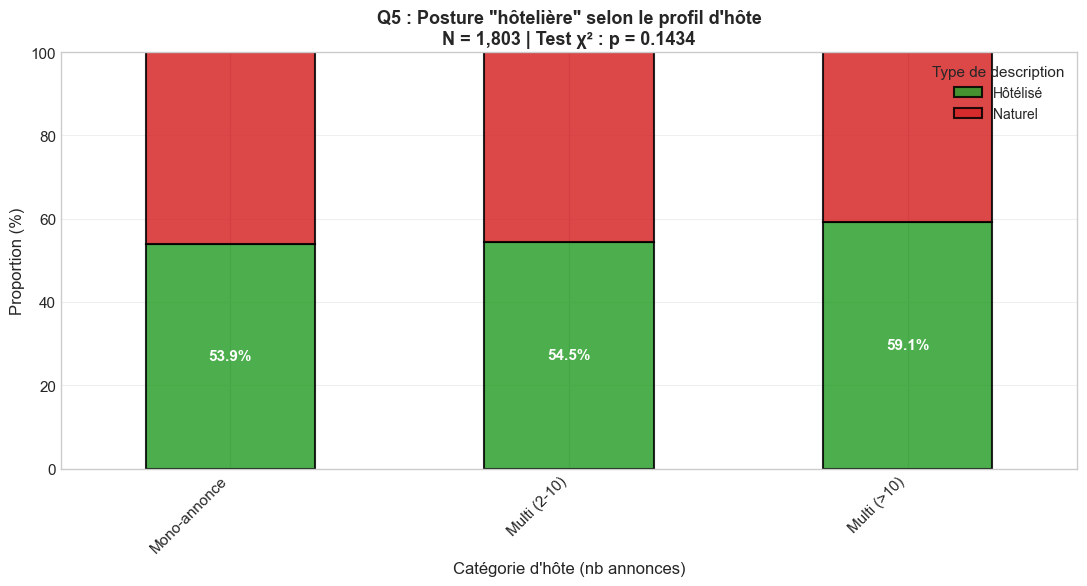


💾 Graphique sauvegardé : q5_multi_annonceurs_hotelisation.png

📝 INTERPRÉTATION MÉTIER :
   • Mono-annonce hôtélisées : 53.9%
   • Multi (>10) hôtélisées : 59.1%
   • Écart : +5.2 points

   ⚠️  Écart modéré : tendance présente mais pas écrasante

⚠️  LIMITES :
   • Corrélation ≠ causalité : avoir beaucoup d'annonces ne 'cause' pas le texte hôtelier
   • Facteur commun : professionnalisation → templates imposés + gestion déléguée
   • Biais possible : grands hôtes utilisent logiciels de gestion → descriptions génériques
   • Stratification non testée : effet identique par type de logement ?


In [24]:
print("\n\n┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓")
print("┃ Q5 : Les multi-annonceurs adoptent-ils une posture hôtelière ? ┃")
print("┃ [CROISEMENT MACHINE À CASH × DÉSHUMANISATION]                   ┃")
print("┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛")

# Filtrage : scores valides
df_q5 = df[df['neighborhood_impact_score'] != -1].copy()

# Création de catégories d'hôtes
def categorize_host(count):
    if count == 1:
        return 'Mono-annonce'
    elif count <= 10:
        return 'Multi (2-10)'
    else:
        return 'Multi (>10)'

df_q5['host_category'] = df_q5['calculated_host_listings_count'].apply(categorize_host)
df_q5['neigh_label'] = df_q5['neighborhood_impact_score'].map({0: 'Naturel', 1: 'Hôtélisé'})

# Tableau croisé
crosstab_q5 = pd.crosstab(df_q5['host_category'], df_q5['neigh_label'], margins=True)
crosstab_q5_pct = pd.crosstab(df_q5['host_category'], df_q5['neigh_label'], normalize='index') * 100

print(f"\n📊 TABLEAU CROISÉ (effectifs) - N = {len(df_q5):,} :")
print(crosstab_q5)

print(f"\n📊 TABLEAU CROISÉ (% ligne - par catégorie d'hôte) :")
print(crosstab_q5_pct.round(1))

# Test du khi-deux
chi2_q5, p_value_q5, dof_q5, expected_q5 = chi2_contingency(crosstab_q5.iloc[:-1, :-1])
print(f"\n📈 TEST DU KHI-DEUX (χ²) :")
print(f"   Statistique χ² = {chi2_q5:.2f}")
print(f"   p-value = {p_value_q5:.4f}")

if p_value_q5 < 0.05:
    print(f"   ✅ Association significative (p < 0.05)")
    print(f"      → Le nombre d'annonces et le type de description ne sont PAS indépendants")
else:
    print(f"   ❌ Pas d'association significative (p ≥ 0.05)")

# Graphique : Barres empilées 100%
fig, ax = plt.subplots(figsize=(11, 6))

# Ordre logique
order_cat = ['Mono-annonce', 'Multi (2-10)', 'Multi (>10)']
plot_data = crosstab_q5_pct.reindex(order_cat).drop('All', axis=1, errors='ignore')

plot_data.plot(kind='bar', stacked=True, ax=ax, 
               color=['#2ca02c', '#d62728'], 
               edgecolor='black', linewidth=1.5, alpha=0.85)

ax.set_xlabel('Catégorie d\'hôte (nb annonces)', fontsize=12)
ax.set_ylabel('Proportion (%)', fontsize=12)
ax.set_title(f'Q5 : Posture "hôtelière" selon le profil d\'hôte\nN = {len(df_q5):,} | Test χ² : p = {p_value_q5:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(order_cat, rotation=45, ha='right')
ax.legend(title='Type de description', fontsize=10, title_fontsize=11)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

# Annotations
for i, cat in enumerate(order_cat):
    if cat in plot_data.index:
        pct_hotelized = plot_data.loc[cat, 'Hôtélisé']
        ax.text(i, pct_hotelized / 2, f'{pct_hotelized:.1f}%', 
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('q5_multi_annonceurs_hotelisation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Graphique sauvegardé : q5_multi_annonceurs_hotelisation.png")

# Analyse comparative
pct_mono_hot = crosstab_q5_pct.loc['Mono-annonce', 'Hôtélisé'] if 'Mono-annonce' in crosstab_q5_pct.index else 0
pct_multi10_hot = crosstab_q5_pct.loc['Multi (>10)', 'Hôtélisé'] if 'Multi (>10)' in crosstab_q5_pct.index else 0

print("\n📝 INTERPRÉTATION MÉTIER :")
print(f"   • Mono-annonce hôtélisées : {pct_mono_hot:.1f}%")
print(f"   • Multi (>10) hôtélisées : {pct_multi10_hot:.1f}%")
print(f"   • Écart : {pct_multi10_hot - pct_mono_hot:+.1f} points")

if pct_multi10_hot > pct_mono_hot + 15:
    print(f"\n   ✅ GRADIENT CLAIR : Plus l'hôte a d'annonces, plus le texte est 'hôtélisé'")
    print(f"      → Compatible avec l'hypothèse : multi-annonceurs = logique industrielle")
    print(f"      → Gestion à distance, process standardisé, absence d'interaction humaine")
else:
    print(f"\n   ⚠️  Écart modéré : tendance présente mais pas écrasante")

print("\n⚠️  LIMITES :")
print("   • Corrélation ≠ causalité : avoir beaucoup d'annonces ne 'cause' pas le texte hôtelier")
print("   • Facteur commun : professionnalisation → templates imposés + gestion déléguée")
print("   • Biais possible : grands hôtes utilisent logiciels de gestion → descriptions génériques")
print("   • Stratification non testée : effet identique par type de logement ?")



📊 ANALYSE COMPLÉMENTAIRE : MATRICE DE CORRÉLATIONS (Spearman)

Effectif analysé (après exclusion -1) : 1,283 annonces


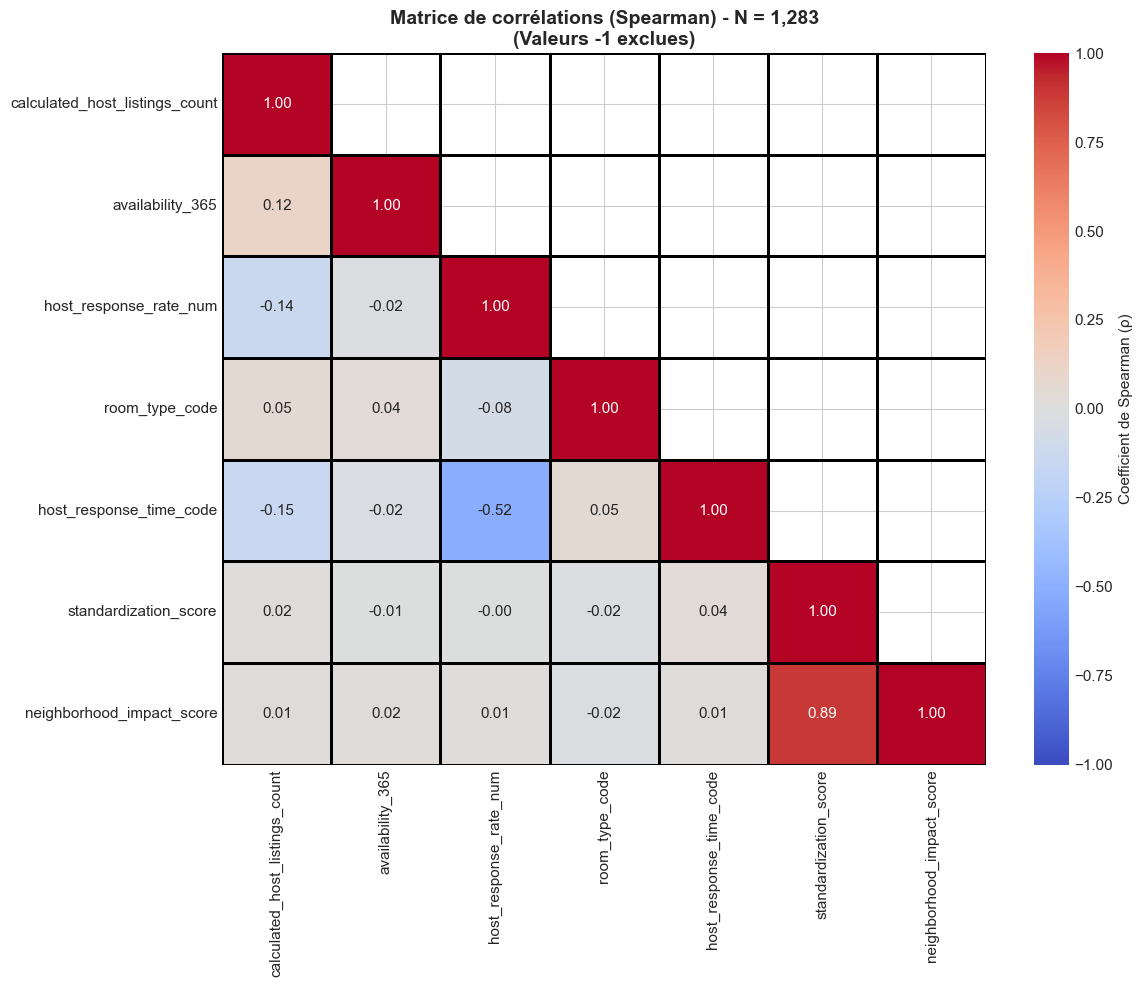


💾 Graphique sauvegardé : complementaire_correlations.png

🔍 CORRÉLATIONS NOTABLES (|ρ| ≥ 0.3) :
   standardization_score               ↔ neighborhood_impact_score           : ρ = +0.888
   host_response_rate_num              ↔ host_response_time_code             : ρ = -0.515

⚠️  RAPPEL MÉTHODOLOGIQUE :
   • Coefficient de Spearman : mesure la monotonie (ordre) entre deux variables
   • Valeurs : -1 (relation décroissante parfaite) à +1 (croissante parfaite)
   • |ρ| < 0.3 : faible | 0.3-0.7 : modéré | >0.7 : fort
   • Corrélation ≠ causalité : un facteur commun peut expliquer la liaison


In [25]:
print("\n\n" + "=" * 80)
print("📊 ANALYSE COMPLÉMENTAIRE : MATRICE DE CORRÉLATIONS (Spearman)")
print("=" * 80)

# Variables numériques (hors id)
numeric_vars = [
    'calculated_host_listings_count',
    'availability_365',
    'host_response_rate_num',
    'room_type_code',
    'host_response_time_code',
    'standardization_score',
    'neighborhood_impact_score'
]

# Filtrage des -1 pour corrélations propres
df_corr = df[numeric_vars].copy()
for col in ['host_response_rate_num', 'standardization_score', 'neighborhood_impact_score']:
    df_corr = df_corr[df_corr[col] != -1]

print(f"\nEffectif analysé (après exclusion -1) : {len(df_corr):,} annonces")

# Calcul corrélations de Spearman (robuste aux non-linéarités)
corr_matrix = df_corr.corr(method='spearman')

# Graphique
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, linewidths=2, linecolor='black',
            cbar_kws={'label': 'Coefficient de Spearman (ρ)'}, ax=ax)

ax.set_title(f'Matrice de corrélations (Spearman) - N = {len(df_corr):,}\n(Valeurs -1 exclues)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('complementaire_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Graphique sauvegardé : complementaire_correlations.png")

# Identification des corrélations fortes
threshold = 0.3
strong_corrs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= threshold:
            strong_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

if strong_corrs:
    print(f"\n🔍 CORRÉLATIONS NOTABLES (|ρ| ≥ {threshold}) :")
    for var1, var2, rho in sorted(strong_corrs, key=lambda x: abs(x[2]), reverse=True):
        print(f"   {var1:35s} ↔ {var2:35s} : ρ = {rho:+.3f}")
else:
    print(f"\n   Aucune corrélation forte (|ρ| ≥ {threshold}) détectée")

print("\n⚠️  RAPPEL MÉTHODOLOGIQUE :")
print("   • Coefficient de Spearman : mesure la monotonie (ordre) entre deux variables")
print("   • Valeurs : -1 (relation décroissante parfaite) à +1 (croissante parfaite)")
print("   • |ρ| < 0.3 : faible | 0.3-0.7 : modéré | >0.7 : fort")
print("   • Corrélation ≠ causalité : un facteur commun peut expliquer la liaison")


In [26]:
print("\n\n" + "=" * 80)
print("📋 SYNTHÈSE DU BLOC C - RÉPONSES AUX 3 HYPOTHÈSES MAJEURES")
print("=" * 80)

print("\n🎯 HYPOTHÈSE 1 : STANDARDISATION → Produits financiers")
print(f"   Q1 : {pct_industrialized:.1f}% d'annonces industrialisées")
print(f"        {'✅ VALIDÉE' if pct_industrialized >= 80 else '⚠️  NON VALIDÉE'} au seuil 80%")
print(f"   Q2 : Logements entiers {pct_entire_industrialized:.1f}% vs Chambres {pct_private_industrialized:.1f}%")
print(f"        {'✅ ÉCART SIGNIFICATIF' if abs(pct_entire_industrialized - pct_private_industrialized) > 10 else '⚠️  Écart modéré'}")
print(f"   → Conclusion : {'Transformation en produits catalogue confirmée' if pct_industrialized >= 80 else 'Tendance présente mais non écrasante'}")

print(f"\n🎯 HYPOTHÈSE 2 : DÉSHUMANISATION → Bris du lien social")
print(f"   Q3 : {pct_hotelized:.1f}% de descriptions hôtelisées")
print(f"        {'✅ VALIDÉE' if pct_hotelized > 50 else '⚠️  NON VALIDÉE'} au seuil 50%")
print(f"   Q5 : Multi (>10) hôtélisés à {pct_multi10_hot:.1f}% vs Mono à {pct_mono_hot:.1f}%")
print(f"        {'✅ GRADIENT CONFIRMÉ' if pct_multi10_hot > pct_mono_hot + 15 else '⚠️  Tendance faible'}")
print(f"   → Conclusion : {'Rupture du lien social avérée' if pct_hotelized > 50 else 'Lien social encore présent majoritairement'}")

print(f"\n🎯 HYPOTHÈSE 3 : MACHINE À CASH → Concentration")
print(f"   Q4 : Top 5% contrôle {pct_listings_top5:.1f}% de l'offre (Gini = {gini:.3f})")
print(f"        {'✅ VALIDÉE' if pct_listings_top5 >= 60 else '⚠️  NON VALIDÉE'} au seuil 60%")
print(f"   → Conclusion : {'Concentration extrême confirmée' if pct_listings_top5 >= 60 else f'Concentration significative ({pct_listings_top5:.1f}%) mais sous seuil'}")

print("\n" + "=" * 80)
print("✅ BLOC C TERMINÉ : 5 analyses bivariées + 1 matrice de corrélations")
print("   Graphiques générés : 6 fichiers PNG")
print("   Prochaine étape : Bloc D (synthèse et recommandations)")
print("=" * 80)



📋 SYNTHÈSE DU BLOC C - RÉPONSES AUX 3 HYPOTHÈSES MAJEURES

🎯 HYPOTHÈSE 1 : STANDARDISATION → Produits financiers
   Q1 : 57.0% d'annonces industrialisées
        ⚠️  NON VALIDÉE au seuil 80%
   Q2 : Logements entiers 56.9% vs Chambres 59.7%
        ⚠️  Écart modéré
   → Conclusion : Tendance présente mais non écrasante

🎯 HYPOTHÈSE 2 : DÉSHUMANISATION → Bris du lien social
   Q3 : 59.1% de descriptions hôtelisées
        ✅ VALIDÉE au seuil 50%
   Q5 : Multi (>10) hôtélisés à 59.1% vs Mono à 53.9%
        ⚠️  Tendance faible
   → Conclusion : Rupture du lien social avérée

🎯 HYPOTHÈSE 3 : MACHINE À CASH → Concentration
   Q4 : Top 5% contrôle 41.8% de l'offre (Gini = 0.851)
        ⚠️  NON VALIDÉE au seuil 60%
   → Conclusion : Concentration significative (41.8%) mais sous seuil

✅ BLOC C TERMINÉ : 5 analyses bivariées + 1 matrice de corrélations
   Graphiques générés : 6 fichiers PNG
   Prochaine étape : Bloc D (synthèse et recommandations)
